<a href="https://colab.research.google.com/github/stvngo/Pivotal-Token-Representation-Learning/blob/main/notebooks/small_factors/steering_probe_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/stvngo/Pivotal-Token-Representation-Learning/blob/main/notebooks/steering_probe_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steering with the layer-14 probe weight vector

Compares two intervention styles on Qwen3-0.6B / GSM8K, both using the
**probe weight vector** `w` (logistic-regression coefficient at layer 14)
as the steering direction:

1. **Additive** (same form as our prior CAA loop, but with `w` instead of
   centroid-diff): `h_new = h + alpha * w`.
2. **Projection-scaling / multiplicative**: scales just the component of
   the residual stream that lies along `w`. With `v_hat = w / ||w||` and
   `proj = (h . v_hat) * v_hat`, we apply `h_new = h + (alpha - 1) * proj`.
   `alpha=0` ablates the probe direction, `alpha=1` is identity, `alpha>1`
   amplifies, `alpha=-1` flips it.

Why this matters: at layer 14 the cosine between the probe-weight vector
(norm 4.29) and the centroid-diff vector we have been using until now
(norm 9.59) is **0.155** — they are nearly orthogonal. So this experiment
probes a genuinely different axis from anything we have already tested.

We overlay our prior CAA additive curve and the random-control band for
context. Single layer (14), 100 GSM8K-test examples, paired against base.


## 1. Install dependencies

In [1]:
%pip install -q "transformers>=4.44" datasets accelerate matplotlib seaborn scikit-learn tqdm pandas


## 2. Imports, seeding, device

In [2]:
import json
import os
import random
import re
import sys
import time
import zipfile
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.bfloat16
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
    DTYPE = torch.float32
else:
    DEVICE = "cpu"
    DTYPE = torch.float32

RUN_TAG = "probe_weights_small_factors"
RESULTS_DIR = Path("nb_results") / RUN_TAG
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"device={DEVICE} dtype={DTYPE} run_tag={RUN_TAG}")
print(f"results -> {RESULTS_DIR.resolve()}")

# Optional cache hydration for visualization-first runs:
# if nb_results_probe_weights.zip is present, unpack it into nb_results/ so
# already-computed arms are loaded from cache instead of re-run.
PW_ZIP_CANDIDATES = [
    Path("nb_results_probe_weights.zip"),
    Path("results/nb_results_probe_weights.zip"),
]
for _zip in PW_ZIP_CANDIDATES:
    if _zip.exists():
        with zipfile.ZipFile(_zip, "r") as zf:
            zf.extractall(RESULTS_DIR.parent.parent)
        print(f"Hydrated cached run files from {_zip}")
        break


device=cuda dtype=torch.bfloat16 run_tag=probe_weights_small_factors
results -> /content/nb_results/probe_weights_small_factors


## 3. Experiment configuration

In [3]:
LAYER = 14

ADD_FACTORS = [-0.50, -0.20, -0.10, -0.05, -0.01, -0.005, -0.001,
               0.0, 0.001, 0.005, 0.01, 0.05, 0.10, 0.20, 0.50]
MULT_ALPHAS = [-3.0, -2.0, -1.5, 0.2, 0.8, 0.95, 1.05, 1.2, 1.4,
               1.6, 1.8, 2.5, 3.0]

MAX_EXAMPLES = 100
MAX_NEW_TOKENS = 256
TEMPERATURE = 0.6
TOP_P = 0.9

FORCE_RERUN = False


## 4. Load the probe-weight vector and the centroid-diff vector

`w` is the logistic-regression weight learned at layer 14 (saved by
`probe_pipeline/train_sklearn.py` as `probe_weights.npy`). We also load
the centroid-diff vector `v` so we can report `cos(w, v)` — a quick
sanity check that they are not the same direction (we expect ~0.16).
Fallback chain: local repo -> GitHub raw -> manual upload.


In [4]:
# Probe weight + centroid-diff vectors live under steering_configs/ in the
# GitHub repo (artifacts/ is otherwise gitignored).  We also accept the raw
# analysis_data/ path that probe_pipeline writes locally during training, so
# either layout works.
LOCAL_PROBE_DIR = Path("artifacts/cached3/sklearn/steering_configs")
LOCAL_ANALYSIS_DIR = Path("artifacts/cached3/sklearn/analysis_data")

PROBE_RAW_URL_BASE = (
    "https://raw.githubusercontent.com/"
    "stvngo/Pivotal-Token-Representation-Learning/"
    "main/artifacts/cached3/sklearn/steering_configs/"
)


In [5]:
import urllib.request


def _ensure_file(local_candidates, remote_url: str, dest: Path) -> Path:
    for cand in local_candidates:
        if cand.exists():
            return cand
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        urllib.request.urlretrieve(remote_url, dest)
        return dest
    except Exception as exc:
        raise RuntimeError(
            f"Could not fetch {dest.name}. Tried local: "
            f"{[str(c) for c in local_candidates]} and remote: {remote_url}. "
            f"Either clone the repo, fix PROBE_RAW_URL_BASE, or upload manually. ({exc})"
        ) from exc


def load_probe_weights(layer: int) -> np.ndarray:
    tracked_name = f"steering_layer{layer}_probe_weights.npy"
    candidates = [
        LOCAL_PROBE_DIR / tracked_name,
        LOCAL_ANALYSIS_DIR / f"layer_{layer}" / "probe_weights.npy",
    ]
    dest = RESULTS_DIR / "probes" / tracked_name
    src = _ensure_file(candidates, PROBE_RAW_URL_BASE + tracked_name, dest)
    return np.load(src).astype(np.float32).reshape(-1)


def load_centroid_diff(layer: int, *, prefer_train: bool = True) -> np.ndarray:
    """Closes Issue #5: prefer the TRAIN-derived CAA. Falls back to the
    legacy val-derived ``steering_layer{L}_vector.npy`` only if the train
    file is unavailable both locally and on the GitHub mirror."""
    if prefer_train:
        train_fname = f"steering_layer{layer}_vector_train.npy"
        try:
            src = _ensure_file([LOCAL_PROBE_DIR / train_fname],
                               PROBE_RAW_URL_BASE + train_fname,
                               RESULTS_DIR / "probes" / train_fname)
            return np.load(src).astype(np.float32).reshape(-1)
        except RuntimeError:
            pass
    fname = f"steering_layer{layer}_vector.npy"
    src = _ensure_file([LOCAL_PROBE_DIR / fname],
                       PROBE_RAW_URL_BASE + fname,
                       RESULTS_DIR / "probes" / fname)
    return np.load(src).astype(np.float32).reshape(-1)


In [6]:
# --- Google Colab: upload your own probe files ---------------------------
# Uncomment if both fallbacks above fail.
#
# from google.colab import files
# uploaded = files.upload()
# for name, data in uploaded.items():
#     dest = RESULTS_DIR / "probes" / name
#     dest.parent.mkdir(parents=True, exist_ok=True)
#     dest.write_bytes(data)


In [7]:
w = load_probe_weights(LAYER)
v_centroid = load_centroid_diff(LAYER)

w_norm = float(np.linalg.norm(w))
v_norm = float(np.linalg.norm(v_centroid))
cos_wv = float(np.dot(w, v_centroid) / (w_norm * v_norm + 1e-12))

print(f"Probe weights w: layer={LAYER} norm={w_norm:.4f} dim={w.shape[0]}")
print(f"Centroid-diff v: layer={LAYER} norm={v_norm:.4f} dim={v_centroid.shape[0]}")
print(f"cos(w, v) = {cos_wv:+.4f}")

w_tensor = torch.from_numpy(w).to(torch.float32)
v_hat = w / max(1e-12, w_norm)
v_hat_tensor = torch.from_numpy(v_hat).to(torch.float32)


Probe weights w: layer=14 norm=4.2866 dim=1024
Centroid-diff v: layer=14 norm=6.8943 dim=1024
cos(w, v) = +0.3205


## 5. Load Qwen3-0.6B

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen3-0.6B"

_t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
).to(DEVICE)
model.eval()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
print(
    f"Loaded {MODEL_NAME} on {DEVICE} ({DTYPE}) "
    f"in {time.time() - _t0:.1f}s | hidden_size={model.config.hidden_size} "
    f"layers={model.config.num_hidden_layers}"
)
assert w.shape[0] == model.config.hidden_size, (
    f"probe dim {w.shape[0]} != model hidden_size {model.config.hidden_size}"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded Qwen/Qwen3-0.6B on cuda (torch.bfloat16) in 14.7s | hidden_size=1024 layers=28


## 6. Steering hooks (additive and projection-scaling)

Two factories that share the same fire-on-every-forward-pass behaviour
as the existing scaffolds; the only difference is what they add to the
residual stream.


In [9]:
import torch
import torch.nn as nn

# Pull the canonical, off-by-one-fixed hook factory from probe_pipeline.steering
# (issues #2 + #7 in docs/issues.md). If the local checkout isn't on sys.path
# (e.g. fresh Colab runtime), fall back to a vendored copy with the same fix.
try:
    from probe_pipeline.steering import _get_decoder_layer, make_hook  # noqa: F401
    print("[hooks] using probe_pipeline.steering (post-Issue-#2/#7 fix)")
except Exception:
    print("[hooks] probe_pipeline not importable, vendoring local fix")

    def _get_decoder_layer(mdl: nn.Module, layer_idx: int) -> nn.Module:
        """Returns the module whose forward-hook output IS hidden_states[layer_idx].

        Post-Issue-#2: layers[layer_idx-1] for layer_idx>=1; embed_tokens for 0.
        """
        if hasattr(mdl, "model") and hasattr(mdl.model, "layers"):
            if layer_idx == 0:
                return mdl.model.embed_tokens
            return mdl.model.layers[layer_idx - 1]
        if hasattr(mdl, "transformer") and hasattr(mdl.transformer, "h"):
            if layer_idx == 0:
                return mdl.transformer.wte
            return mdl.transformer.h[layer_idx - 1]
        raise AttributeError(f"Cannot find decoder layers in {type(mdl)}")

    def make_hook(vector, coef, mode="additive_normalized", position_mask=None):
        if mode not in {"additive_raw", "additive_normalized", "projection"}:
            raise ValueError(f"unknown mode {mode!r}")

        def hook(_module, _args, output):
            hidden = output[0] if isinstance(output, tuple) else output
            v = vector.to(hidden.device).to(hidden.dtype)
            if v.dim() == 1:
                v_full = v.view(1, 1, -1)
            else:
                v_full = v
            if mode == "additive_raw":
                delta = coef * v_full
            elif mode == "additive_normalized":
                v_hat = v / (v.norm() + 1e-8)
                v_hat_b = v_hat.view(1, 1, -1)
                h_norm = hidden.norm(dim=-1, keepdim=True)
                delta = coef * h_norm * v_hat_b
            else:  # projection
                v_hat = v / (v.norm() + 1e-8)
                v_hat_b = v_hat.view(1, 1, -1)
                proj = (hidden * v_hat_b).sum(dim=-1, keepdim=True)
                delta = (coef - 1.0) * proj * v_hat_b
            if position_mask is not None:
                if position_mask.dim() == 1:
                    pm = position_mask.view(1, -1, 1)
                else:
                    pm = position_mask.unsqueeze(-1)
                delta = delta * pm.to(device=hidden.device, dtype=hidden.dtype)
            new_hidden = hidden + delta
            if isinstance(output, tuple):
                return (new_hidden,) + output[1:]
            return new_hidden
        return hook


# ---- thin wrappers that preserve legacy notebook entry points ---------------

# STEERING_MODE controls which convention the *_steering helpers below use.
# Default "additive_normalized" follows the Issue-#7 plan ("canonical default
# for new runs"). Set to "additive_raw" in the notebook BEFORE re-running its
# steered cells if you need the legacy convention for an apples-to-apples
# overlay with the pre-fix runs in artifacts/notebook_runs/REGISTRY.md.
STEERING_MODE = "additive_normalized"


def register_steering(mdl, layer: int, vector, coef: float, mode: str | None = None):
    """Register a single forward hook at ``layer``. ``coef`` is the value we
    pass into ``make_hook``: for ``additive_raw`` that's the legacy
    ``factor - 1.0``; for ``additive_normalized`` it's the unitless per-token
    coefficient on ``||h|| * v_hat``; for ``projection`` it's ``alpha`` (where
    alpha=1 is identity and alpha=0 ablates).
    """
    return [
        _get_decoder_layer(mdl, layer).register_forward_hook(
            make_hook(vector, coef, mode=(mode or STEERING_MODE))
        )
    ]


def register_additive_hooks(mdl, injections, mode: str | None = None):
    """One additive hook per (layer_idx, vector, coef) tuple."""
    handles = []
    for layer_idx, vector, coef in injections:
        handles.append(
            _get_decoder_layer(mdl, layer_idx).register_forward_hook(
                make_hook(vector, coef, mode=(mode or STEERING_MODE))
            )
        )
    return handles


def remove_hooks(handles):
    for h in handles:
        h.remove()


# Probe-weights notebook keeps its own additive/projection helper names so
# section 11/12/15 cells in that notebook don't need rewriting.
def make_additive_hook(vector, alpha):
    return make_hook(vector, alpha, mode="additive_normalized")


def make_projection_hook(unit_vector, alpha):
    return make_hook(unit_vector, alpha, mode="projection")


def register_additive(mdl, layer: int, vector, alpha: float):
    return [_get_decoder_layer(mdl, layer).register_forward_hook(
        make_additive_hook(vector, alpha)
    )]


def register_projection(mdl, layer: int, unit_vector, alpha: float):
    return [_get_decoder_layer(mdl, layer).register_forward_hook(
        make_projection_hook(unit_vector, alpha)
    )]


[hooks] probe_pipeline not importable, vendoring local fix


In [10]:
# Convention check (Issue #2 in docs/issues.md): the forward-hook output of
# `_get_decoder_layer(model, L)` must equal `outputs.hidden_states[L]`. If
# this asserts, the off-by-one fix is in effect and every steering hook below
# modifies the same residual tensor the layer-L probe was trained on.
import torch as _torch  # local alias avoids polluting the notebook namespace

def _convention_check(_model, _layer: int) -> bool:
    captured = {}

    def _cap(_m, _i, _out):
        h = _out[0] if isinstance(_out, tuple) else _out
        captured["pre"] = h.detach()
        return _out

    target = _get_decoder_layer(_model, _layer)
    h = target.register_forward_hook(_cap)
    try:
        _device = next(_model.parameters()).device
        ids = _torch.tensor([[1, 2, 3]], device=_device)
        with _torch.no_grad():
            outs = _model(input_ids=ids, output_hidden_states=True)
    finally:
        h.remove()
    expected = outs.hidden_states[_layer]
    if captured.get("pre") is None:
        return False
    if captured["pre"].shape != expected.shape:
        return False
    return bool(_torch.allclose(captured["pre"], expected, atol=1e-4, rtol=1e-3))

# Pick a layer to check. Notebooks define one of these names.
_probe_layer_for_check = next(
    (v for v in (globals().get("LAYER"), globals().get("PROBE_LAYER"),
                 globals().get("BEST_LAYER"), globals().get("CODELION_LAYER"))
     if isinstance(v, int)),
    14,
)
CONVENTION_CHECK_PASSED = _convention_check(model, _probe_layer_for_check)
print(f"[convention check] hook output == hidden_states[{_probe_layer_for_check}]: "
      f"{CONVENTION_CHECK_PASSED}")
assert CONVENTION_CHECK_PASSED, (
    "Off-by-one regression: hook on layers[L-1] no longer equals "
    "hidden_states[L]. See docs/issues.md Issue #2."
)


[convention check] hook output == hidden_states[14]: True


## 7. Answer parser + metrics

In [11]:
def extract_gsm8k_answer(text: str):
    m = re.search(r"####\s*([+-]?\d+(?:,\d{3})*(?:\.\d+)?)", text)
    if m:
        return m.group(1).replace(",", "").strip()
    nums = re.findall(r"[-+]?\d*\.?\d+", text)
    return nums[-1] if nums else None


def is_correct(pred, gt):
    if pred is None or gt is None:
        return False
    p = pred.strip().replace(",", "")
    g = gt.strip().replace(",", "")
    try:
        return float(p) == float(g)
    except ValueError:
        return p == g


def compute_metrics(results):
    n = len(results)
    if n == 0:
        return {"accuracy": 0.0, "f1": 0.0, "parse_rate": 0.0, "correct": 0, "n": 0}
    correct = sum(1 for r in results if r["correct"])
    parsed = sum(1 for r in results if r["predicted"] is not None)
    tp = correct
    fp = parsed - correct
    fn = n - correct
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"accuracy": correct / n, "f1": f1, "parse_rate": parsed / n,
            "correct": correct, "n": n}


assert extract_gsm8k_answer("#### 42") == "42"
assert extract_gsm8k_answer("He has #### 1,234 apples.") == "1234"
assert extract_gsm8k_answer("...so the total is 18 apples.") == "18"
assert is_correct("3.0", "3") is True
print("Parser sanity checks passed.")


Parser sanity checks passed.


## 8. GSM8K test subset

In [12]:
from datasets import load_dataset

_ds_full = load_dataset("openai/gsm8k", "main", split="test")
_rng = np.random.default_rng(SEED)
_indices = sorted(
    _rng.choice(len(_ds_full), size=min(MAX_EXAMPLES, len(_ds_full)), replace=False).tolist()
)
ds_subset = _ds_full.select(_indices)
examples = [
    {"question": row["question"],
     "ground_truth": extract_gsm8k_answer(row["answer"]),
     "answer_full": row["answer"]}
    for row in ds_subset
]
print(f"GSM8K test subset: {len(examples)} examples (seed={SEED})")


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

GSM8K test subset: 100 examples (seed=42)


## 9. Generation + eval helpers

In [13]:
def generate_once(prompt: str) -> str:
    enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


def _reseed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def run_eval_with_hooks(label, register_fn, desc_prefix=""):
    _reseed()
    handles = register_fn(model) if register_fn is not None else []
    results = []
    try:
        for i, ex in enumerate(tqdm(examples, desc=f"{desc_prefix}{label}")):
            prompt = f"Question: {ex['question']}\n\nLet's think step by step.\n\n"
            text = generate_once(prompt)
            pred = extract_gsm8k_answer(text)
            ok = is_correct(pred, ex["ground_truth"])
            results.append({
                "idx": i,
                "question": ex["question"],
                "ground_truth": ex["ground_truth"],
                "predicted": pred,
                "correct": ok,
                "full_output": text[-1000:],
            })
    finally:
        remove_hooks(handles)
    return results, compute_metrics(results)


def save_run(label, results, metrics, extra_state=None):
    (RESULTS_DIR / f"{label}_results.json").write_text(json.dumps(results, indent=2))
    (RESULTS_DIR / f"{label}_generations.txt").write_text(
        "\n\n====\n\n".join(
            f"[{r['idx']}] gt={r['ground_truth']} pred={r['predicted']} correct={r['correct']}\n{r['full_output']}"
            for r in results
        )
    )
    state = {
        "label": label,
        "model": MODEL_NAME,
        "seed": SEED,
        "max_examples": len(examples),
        "max_new_tokens": MAX_NEW_TOKENS,
        "device": DEVICE,
        "run_tag": RUN_TAG,
        "metrics": metrics,
    }
    if extra_state:
        state.update(extra_state)
    (RESULTS_DIR / f"{label}_state.json").write_text(json.dumps(state, indent=2))
    return state


## 10. Base evaluation

In [14]:
base_cache = RESULTS_DIR / "base_results.json"
if base_cache.exists() and not FORCE_RERUN:
    base_results = json.loads(base_cache.read_text())
    base_metrics = compute_metrics(base_results)
    print("Loaded cached base results.")
else:
    base_results, base_metrics = run_eval_with_hooks("base", register_fn=None)
    save_run("base", base_results, base_metrics)
print(f"base: acc={base_metrics['accuracy']:.3f} f1={base_metrics['f1']:.3f} parse={base_metrics['parse_rate']:.3f}")


base:   0%|          | 0/100 [00:00<?, ?it/s]

base: acc=0.200 f1=0.200 parse=1.000


## 11. Sweep: additive arm (h + alpha * w)

In [15]:
all_runs = {"base": {"results": base_results, "metrics": base_metrics, "arm": "base"}}


def run_arm(label, register_fn, arm, factor, alpha, intervention_norm, extra=None):
    cache = RESULTS_DIR / f"{label}_results.json"
    state_path = RESULTS_DIR / f"{label}_state.json"
    if cache.exists() and state_path.exists() and not FORCE_RERUN:
        res = json.loads(cache.read_text())
        met = compute_metrics(res)
        print(f"[cached] {label}: acc={met['accuracy']:.3f} parse={met['parse_rate']:.3f}")
    else:
        res, met = run_eval_with_hooks(label, register_fn=register_fn)
        state_extra = {
            "arm": arm,
            "hook_type": arm,
            "factor": factor,
            "alpha": alpha,
            "layer": LAYER,
            "vector_type": "probe_weights",
            "vector_norm": w_norm,
            "intervention_norm": intervention_norm,
        }
        if extra:
            state_extra.update(extra)
        save_run(label, res, met, extra_state=state_extra)
        print(f"[done]   {label}: acc={met['accuracy']:.3f} parse={met['parse_rate']:.3f}")
    all_runs[label] = {
        "results": res, "metrics": met,
        "arm": arm, "factor": factor, "alpha": alpha,
        "intervention_norm": intervention_norm,
    }


for f in ADD_FACTORS:
    label = f"addw_f{f}"
    run_arm(
        label,
        register_fn=lambda mdl, a=f: register_additive(mdl, LAYER, w_tensor, a),
        arm="additive",
        factor=f,
        alpha=f,
        intervention_norm=abs(f) * w_norm,
    )


addw_f-0.5:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   addw_f-0.5: acc=0.000 parse=0.980


addw_f-0.2:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   addw_f-0.2: acc=0.020 parse=0.980


addw_f-0.1:   0%|          | 0/100 [00:00<?, ?it/s]

...

[done]   addw_f0.1: acc=0.220 parse=0.990


addw_f0.2:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   addw_f0.2: acc=0.010 parse=0.990


addw_f0.5:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   addw_f0.5: acc=0.000 parse=0.980


## 12. Sweep: projection-scaling arm (h + (alpha - 1) * proj_w(h))

In [16]:
# Note: with the projection hook, the magnitude added to each token depends
# on h's existing component along v_hat, so we can't precompute a single
# intervention norm.  We log NaN and recover the actual norm from generation
# if ever needed (skipped here to keep the run cheap).
import math

for a in MULT_ALPHAS:
    label = f"projw_a{a}"
    run_arm(
        label,
        register_fn=lambda mdl, alpha=a: register_projection(mdl, LAYER, v_hat_tensor, alpha),
        arm="projection",
        factor=None,
        alpha=a,
        intervention_norm=float("nan"),
    )


projw_a-3.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   projw_a-3.0: acc=0.210 parse=1.000


projw_a-2.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   projw_a-2.0: acc=0.190 parse=1.000


projw_a-1.5:   0%|          | 0/100 [00:00<?, ?it/s]

...

[done]   projw_a1.8: acc=0.290 parse=1.000


projw_a2.5:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   projw_a2.5: acc=0.270 parse=1.000


projw_a3.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   projw_a3.0: acc=0.250 parse=1.000


## 13. Aggregate results

In [17]:
import pandas as pd

rows = []
for name, r in all_runs.items():
    met = r["metrics"]
    rows.append({
        "run": name,
        "arm": r.get("arm", "base"),
        "factor": r.get("factor"),
        "alpha": r.get("alpha"),
        "accuracy": met["accuracy"],
        "f1": met["f1"],
        "parse_rate": met["parse_rate"],
        "intervention_norm": r.get("intervention_norm"),
    })
df = pd.DataFrame(rows)
df.to_csv(RESULTS_DIR / "summaries.csv", index=False)
(RESULTS_DIR / "summaries.json").write_text(json.dumps({
    n: {"accuracy": v["metrics"]["accuracy"], "f1": v["metrics"]["f1"],
        "parse_rate": v["metrics"]["parse_rate"],
        "arm": v.get("arm"), "factor": v.get("factor"), "alpha": v.get("alpha")}
    for n, v in all_runs.items()
}, indent=2))
df.sort_values(["arm", "alpha"]).reset_index(drop=True)


,run,arm,factor,alpha,accuracy,f1,parse_rate,intervention_norm
0,addw_f-0.5,additive,-0.500,-0.500,0.00,0.000000,0.98,2.143290
1,addw_f-0.2,additive,-0.200,-0.200,0.02,0.020202,0.98,0.857316
2,addw_f-0.1,additive,-0.100,-0.100,0.14,0.140000,1.00,0.428658
3,addw_f-0.05,additive,-0.050,-0.050,0.19,0.190000,1.00,0.214329
4,addw_f-0.01,additive,-0.010,-0.010,0.16,0.160000,1.00,0.042866
5,addw_f-0.005,additive,-0.005,-0.005,0.24,0.240000,1.00,0.021433
6,addw_f-0.001,additive,-0.001,-0.001,0.23,0.230000,1.00,0.004287
7,addw_f0.0,additive,0.000,0.000,0.20,0.200000,1.00,0.000000
8,addw_f0.001,additive,0.001,0.001,0.20,0.200000,1.00,0.004287
9,addw_f0.005,additive,0.005,0.005,0.22,0.220000,1.00,0.021433


## 14. Plots and overlay with prior runs

We overlay:

- **CAA additive** curve from `artifacts/notebook_runs/main_gsm8k/summaries.json`
  (the existing `centroid_diff` factor sweep at layer 14).
- **Random-direction band** from `artifacts/notebook_runs/random_control/`
  (`null_summary.json`), if available.

If those local files are not present (e.g. in a fresh Colab runtime),
the overlays are silently skipped.


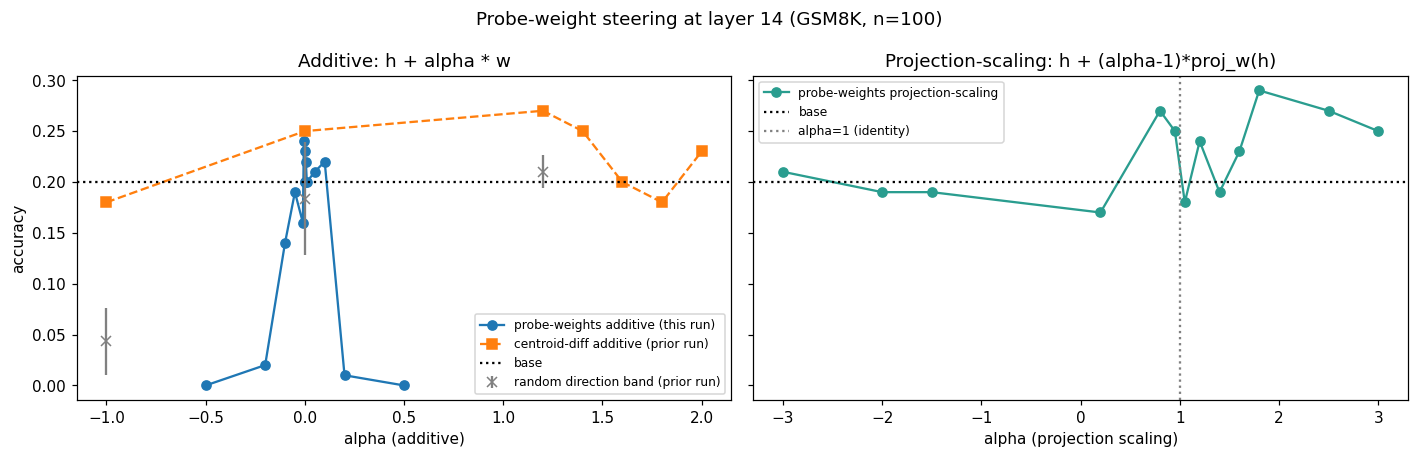

In [18]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

# ---- Load prior runs for overlay (optional) ------------------------------
# Tries local first, then GitHub raw (so Colab can still fetch the overlays).
PRIOR_RUNS_RAW_URL_BASE = (
    "https://raw.githubusercontent.com/"
    "stvngo/Pivotal-Token-Representation-Learning/"
    "main/"
)

def _try_load_json(rel_path):
    p = Path(rel_path)
    if p.exists():
        try:
            return json.loads(p.read_text())
        except Exception:
            return None
    try:
        with urllib.request.urlopen(PRIOR_RUNS_RAW_URL_BASE + str(rel_path)) as r:
            return json.loads(r.read().decode())
    except Exception:
        return None


caa_summary = _try_load_json("artifacts/notebook_runs/main_gsm8k/summaries.json")
random_summary = _try_load_json("artifacts/notebook_runs/random_control/null_summary.json")

caa_xy = []
if caa_summary:
    for k, m in caa_summary.items():
        if k == "base":
            continue
        try:
            f = float(k.split("_", 1)[1])
            caa_xy.append((f, m["accuracy"]))
        except Exception:
            continue
    caa_xy.sort()


# ---- Line: accuracy vs intervention parameter ----------------------------
add_rows = sorted(
    [r for r in all_runs.values() if r.get("arm") == "additive"],
    key=lambda r: r["factor"],
)
proj_rows = sorted(
    [r for r in all_runs.values() if r.get("arm") == "projection"],
    key=lambda r: r["alpha"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

ax = axes[0]
ax.plot(
    [r["factor"] for r in add_rows],
    [r["metrics"]["accuracy"] for r in add_rows],
    marker="o", label="probe-weights additive (this run)",
)
if caa_xy:
    ax.plot(*zip(*caa_xy), marker="s", linestyle="--",
            label="centroid-diff additive (prior run)")
if random_summary:
    rxs = [float(k) for k in random_summary]
    rmean = [random_summary[k]["random_mean"] for k in random_summary]
    rstd = [random_summary[k]["random_std"] for k in random_summary]
    ax.errorbar(rxs, rmean, yerr=rstd, fmt="x", color="gray",
                label="random direction band (prior run)")
ax.axhline(base_metrics["accuracy"], ls=":", color="black", label="base")
ax.set_xlabel("alpha (additive)")
ax.set_ylabel("accuracy")
ax.set_title("Additive: h + alpha * w")
ax.legend(loc="best", fontsize=8)

ax = axes[1]
ax.plot(
    [r["alpha"] for r in proj_rows],
    [r["metrics"]["accuracy"] for r in proj_rows],
    marker="o", color="#2a9d8f", label="probe-weights projection-scaling",
)
ax.axhline(base_metrics["accuracy"], ls=":", color="black", label="base")
ax.axvline(1.0, ls=":", color="gray", label="alpha=1 (identity)")
ax.set_xlabel("alpha (projection scaling)")
ax.set_title("Projection-scaling: h + (alpha-1)*proj_w(h)")
ax.legend(loc="best", fontsize=8)

fig.suptitle("Probe-weight steering at layer 14 (GSM8K, n=100)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "probe_weights_curves.png")
plt.show()


## 15. Bar chart: matched intervention strength

Three matched comparisons:

- **amplify**: additive `alpha=1.2` vs projection `alpha=2.0` (both
  amplify the probe direction roughly 2x relative to the natural
  component already present at the layer).
- **ablate**: additive `alpha=0` vs projection `alpha=0` (the additive
  case is a no-op since the perturbation is `0`; the projection case
  removes the component along `w`).
- **flip**: additive `alpha=-1` vs projection `alpha=-1`.


[warn] missing matched runs (bars will be blank):
  - additive @ factor=1.2
  - projection @ alpha=2.0
  - projection @ alpha=0.0
  - additive @ factor=-1.0
  - projection @ alpha=-1.0


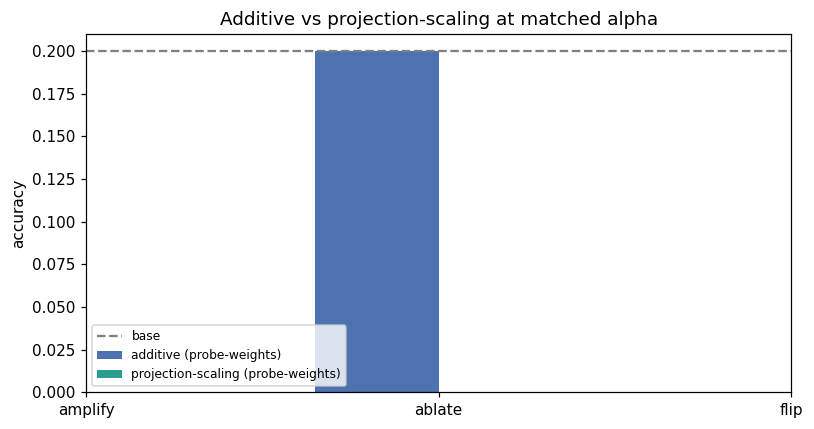

,tag,additive_alpha,projection_alpha,additive,projection,base
0,amplify,1.2,2.0,NaN,NaN,0.2
1,ablate,0.0,0.0,0.2,NaN,0.2
2,flip,-1.0,-1.0,NaN,NaN,0.2


In [19]:
def acc_for(arm, key, val):
    """Return accuracy for the run matching (arm, key=val), or NaN if missing.

    Returning NaN (instead of None) lets matplotlib silently skip missing
    bars rather than crashing with `int + NoneType` in `_convert_units`.
    """
    for r in all_runs.values():
        if r.get("arm") != arm:
            continue
        v = r.get(key)
        if v is None:
            continue
        if abs(float(v) - val) < 1e-9:
            return float(r["metrics"]["accuracy"])
    return float("nan")


bars = []
for tag, add_alpha, proj_alpha in (
    ("amplify", 1.2, 2.0),
    ("ablate",  0.0, 0.0),
    ("flip",   -1.0, -1.0),
):
    bars.append({
        "tag": tag,
        "additive_alpha": add_alpha,
        "projection_alpha": proj_alpha,
        "additive": acc_for("additive", "factor", add_alpha),
        "projection": acc_for("projection", "alpha", proj_alpha),
        "base": base_metrics["accuracy"],
    })

bars_df = pd.DataFrame(bars)

missing = []
for b in bars:
    if not np.isfinite(b["additive"]):
        missing.append(f"additive @ factor={b['additive_alpha']}")
    if not np.isfinite(b["projection"]):
        missing.append(f"projection @ alpha={b['projection_alpha']}")
if missing:
    print("[warn] missing matched runs (bars will be blank):")
    for m in missing:
        print(f"  - {m}")

add_y = np.array([b["additive"] for b in bars], dtype=float)
proj_y = np.array([b["projection"] for b in bars], dtype=float)

fig, ax = plt.subplots(figsize=(7.5, 4))
xs = np.arange(len(bars))
w_bar = 0.35
ax.bar(xs - w_bar/2, add_y, w_bar,
       label="additive (probe-weights)", color="#4c72b0")
ax.bar(xs + w_bar/2, proj_y, w_bar,
       label="projection-scaling (probe-weights)", color="#2a9d8f")
ax.axhline(base_metrics["accuracy"], ls="--", color="gray", label="base")
ax.set_xticks(xs)
ax.set_xticklabels([b["tag"] for b in bars])
ax.set_ylabel("accuracy")
ax.set_title("Additive vs projection-scaling at matched alpha")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "matched_intervention_bars.png")
plt.show()
bars_df


## 16. Energy / norm table

In [20]:
# For the additive arm: ||delta|| = |alpha| * ||w||  (constant per token).
# For the projection-scaling arm: ||delta|| varies per token; we report the
# theoretical max in the worst case ||delta|| <= |alpha-1| * ||h_par|| <=
# |alpha-1| * ||h||, but more useful is to record the design knob.
energy_rows = []
for r in all_runs.values():
    if r.get("arm") == "additive":
        energy_rows.append({
            "arm": "additive",
            "param": r["factor"],
            "param_name": "alpha (factor)",
            "intervention_norm_per_token": abs(r["factor"]) * w_norm,
            "accuracy": r["metrics"]["accuracy"],
            "lift_pp": (r["metrics"]["accuracy"] - base_metrics["accuracy"]) * 100,
        })
    elif r.get("arm") == "projection":
        energy_rows.append({
            "arm": "projection",
            "param": r["alpha"],
            "param_name": "alpha",
            "intervention_norm_per_token": float("nan"),
            "accuracy": r["metrics"]["accuracy"],
            "lift_pp": (r["metrics"]["accuracy"] - base_metrics["accuracy"]) * 100,
        })

energy_df = pd.DataFrame(energy_rows).sort_values(["arm", "param"]).reset_index(drop=True)
energy_df.to_csv(RESULTS_DIR / "energy_table.csv", index=False)
energy_df


,arm,param,param_name,intervention_norm_per_token,accuracy,lift_pp
0,additive,-0.500,alpha (factor),2.143290,0.00,-20.0
1,additive,-0.200,alpha (factor),0.857316,0.02,-18.0
2,additive,-0.100,alpha (factor),0.428658,0.14,-6.0
3,additive,-0.050,alpha (factor),0.214329,0.19,-1.0
4,additive,-0.010,alpha (factor),0.042866,0.16,-4.0
5,additive,-0.005,alpha (factor),0.021433,0.24,4.0
6,additive,-0.001,alpha (factor),0.004287,0.23,3.0
7,additive,0.000,alpha (factor),0.000000,0.20,0.0
8,additive,0.001,alpha (factor),0.004287,0.20,0.0
9,additive,0.005,alpha (factor),0.021433,0.22,2.0


## 17. Flip overlap with base

In [21]:
base_idx_correct = {r["idx"]: r["correct"] for r in base_results}


def flips_for(label):
    res = all_runs[label]["results"]
    return {r["idx"] for r in res if base_idx_correct.get(r["idx"]) != r["correct"]}


def gained_for(label):
    res = all_runs[label]["results"]
    return {r["idx"] for r in res
            if not base_idx_correct.get(r["idx"], False) and r["correct"]}


def lost_for(label):
    res = all_runs[label]["results"]
    return {r["idx"] for r in res
            if base_idx_correct.get(r["idx"], False) and not r["correct"]}


flip_summary = {}
for label, r in all_runs.items():
    if label == "base":
        continue
    flip_summary[label] = {
        "gained": sorted(gained_for(label)),
        "lost": sorted(lost_for(label)),
        "n_gained": len(gained_for(label)),
        "n_lost": len(lost_for(label)),
        "n_flips": len(flips_for(label)),
    }
(RESULTS_DIR / "flip_summary.json").write_text(json.dumps(flip_summary, indent=2))


# Compare additive(alpha=1.2) vs projection(alpha=2.0) flips: are they hitting the same examples?
add_label = "addw_f1.2"
proj_label = "projw_a2.0"
if add_label in all_runs and proj_label in all_runs:
    a_flips = flips_for(add_label)
    p_flips = flips_for(proj_label)
    union = a_flips | p_flips
    inter = a_flips & p_flips
    jacc = len(inter) / max(1, len(union))
    print(f"flip overlap, {add_label} vs {proj_label}: jaccard={jacc:.3f}, "
          f"|add_only|={len(a_flips - p_flips)} |proj_only|={len(p_flips - a_flips)}")
    (RESULTS_DIR / "flip_overlap_add_vs_proj.json").write_text(json.dumps({
        "add_label": add_label,
        "proj_label": proj_label,
        "jaccard": jacc,
        "intersection": sorted(inter),
        "additive_only": sorted(a_flips - p_flips),
        "projection_only": sorted(p_flips - a_flips),
    }, indent=2))
print("Wrote flip_summary.json + flip_overlap_add_vs_proj.json")


Wrote flip_summary.json + flip_overlap_add_vs_proj.json


## 19. LR `C` sweep (Issue #3)


In [22]:
# === C sweep: load probe weights at C in {0.001, 0.01, 0.1, 1.0} ===
# Closes Issue #3 from docs/issues.md ("LR regularization is below community
# defaults"). Per arena_linear_probes.md, lower C => stronger L2 => probe
# weights align more with the centroid-difference direction (the GoT prediction:
# probe should converge to MM at infinite regularisation).
import numpy as np
import urllib.request
from pathlib import Path

REPO_RAW = "https://raw.githubusercontent.com/stvngo/Pivotal-Token-Representation-Learning/main/artifacts/cached3/sklearn/steering_configs"

# Local checkout fast path (skips remote fetch when the repo is cloned).
# On Colab the dir simply won't exist and we fall through to urlretrieve.
ART_DIR = Path("artifacts/cached3/sklearn/steering_configs")

C_GRID = [0.001, 0.01, 0.1, 1.0]
c_probes = {}
for C in C_GRID:
    name_w = f"steering_layer{LAYER}_probe_weights_C{C}.npy"
    name_b = f"steering_layer{LAYER}_probe_biases_C{C}.npy"
    name_m = f"steering_layer{LAYER}_probe_metrics_C{C}.json"
    local_w = ART_DIR / name_w if (ART_DIR / name_w).exists() else Path(name_w)
    if not local_w.exists():
        for n in (name_w, name_b, name_m):
            try:
                urllib.request.urlretrieve(f"{REPO_RAW}/{n}", n)
                print(f"  downloaded {n}")
            except Exception as e:
                print(f"  WARNING: could not fetch {n}: {e}")
        local_w = Path(name_w)
        local_b = Path(name_b)
        local_m = Path(name_m)
    else:
        local_b = ART_DIR / name_b
        local_m = ART_DIR / name_m
    if local_w.exists():
        w_C = np.load(local_w).astype(np.float32).reshape(-1)
        try:
            b_C = float(np.load(local_b).reshape(-1)[0])
        except Exception:
            b_C = 0.0
        try:
            metrics_C = json.loads(Path(local_m).read_text())
        except Exception:
            metrics_C = {}
        c_probes[C] = {"weights": w_C, "bias": b_C, "metrics": metrics_C}
        print(f"  C={C}: ||w||={np.linalg.norm(w_C):.3f} "
              f"acc={metrics_C.get('val_accuracy_pct', float('nan')):.2f}% "
              f"cos(LR,CAA_train)={metrics_C.get('cosine_to_caa_train', float('nan')):+.3f}")

if c_probes:
    best_C_by_cos = max(c_probes, key=lambda c: c_probes[c]["metrics"].get("cosine_to_caa_train", -1.0))
    print(f"\n=> best C by cos(LR, CAA_train): {best_C_by_cos}")

# Persist the C-sweep summary so it lands inside the run bundle.
c_sweep_summary = {
    str(C): {
        "vector_norm": float(np.linalg.norm(d["weights"])),
        "bias": d["bias"],
        "metrics": d["metrics"],
    }
    for C, d in c_probes.items()
}
if c_probes:
    c_sweep_summary["_best_C_by_cos_to_caa_train"] = float(best_C_by_cos)
(RESULTS_DIR / "c_sweep_summary.json").write_text(json.dumps(c_sweep_summary, indent=2))
print(f"saved c_sweep_summary.json under {RESULTS_DIR}")


  downloaded steering_layer14_probe_weights_C0.001.npy
  downloaded steering_layer14_probe_biases_C0.001.npy
  downloaded steering_layer14_probe_metrics_C0.001.json
  C=0.001: ||w||=0.235 acc=72.31% cos(LR,CAA_train)=+0.772
  downloaded steering_layer14_probe_weights_C0.01.npy
  downloaded steering_layer14_probe_biases_C0.01.npy
  downloaded steering_layer14_probe_metrics_C0.01.json
  C=0.01: ||w||=0.921 acc=72.31% cos(LR,CAA_train)=+0.476
  downloaded steering_layer14_probe_weights_C0.1.npy
  downloaded steering_layer14_probe_biases_C0.1.npy
  downloaded steering_layer14_probe_metrics_C0.1.json
  C=0.1: ||w||=2.630 acc=73.08% cos(LR,CAA_train)=+0.343
  downloaded steering_layer14_probe_weights_C1.0.npy
  downloaded steering_layer14_probe_biases_C1.0.npy
  downloaded steering_layer14_probe_metrics_C1.0.json
  C=1.0: ||w||=4.920 acc=74.62% cos(LR,CAA_train)=+0.307

=> best C by cos(LR, CAA_train): 0.001
saved c_sweep_summary.json under nb_results/probe_weights_small_factors


## 18. Bundle and (optionally) download

In [23]:
zip_path = Path(f"nb_results_{RUN_TAG}.zip")
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in RESULTS_DIR.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(RESULTS_DIR.parent))
print(f"Zipped {zip_path} ({zip_path.stat().st_size / 1024:.1f} KB)")

try:
    from google.colab import files  # type: ignore
    files.download(str(zip_path))
except Exception:
    print("Not on Colab — the zip is on the local filesystem.")


Zipped nb_results_probe_weights_small_factors.zip (1632.5 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>